# MLB Game Winner — Model Training

Loads the pre-built feature matrix from the data pipeline notebook,
runs a grid search over hyperparameters (each logged to MLflow),
trains the final model with the best params, and evaluates on a holdout set.

**Run `data_pipeline.ipynb` first** to generate `artifacts/dataset.pkl`.


## 1. Setup

In [1]:
import os, sys, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score, accuracy_score)
import mlflow
import mlflow.sklearn

MODEL_DIR = os.path.abspath(".")
if MODEL_DIR not in sys.path:
    sys.path.insert(0, MODEL_DIR)

ARTIFACTS_DIR = os.path.join(MODEL_DIR, "artifacts")
MODEL_PATH    = os.path.join(ARTIFACTS_DIR, "model.pkl")

MLFLOW_TRACKING_URI = os.path.join(MODEL_DIR, "mlruns")
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment("mlb-game-predictor-v1")
print(f"MLflow tracking URI: {MLFLOW_TRACKING_URI}")


/Users/nickchapman/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


MLflow tracking URI: /Users/nickchapman/pitch_predictor/backend/model/mlruns


## 2. Load Dataset

In [6]:
DATA_PATH = os.path.join(ARTIFACTS_DIR, "dataset.pkl")

with open(DATA_PATH, "rb") as f:
    dataset = pickle.load(f)

X              = dataset["X"].copy()
y              = dataset["y"].copy()
holdout_X      = dataset["holdout_X"].copy()
holdout_y      = dataset["holdout_y"].copy()
final_features = dataset["final_features"]
WINDOW         = dataset["WINDOW"]
YEARS          = dataset["YEARS"]

print(f"X: {X.shape}, holdout_X: {holdout_X.shape}")
print(f"Features: {len(final_features)}, Window: {WINDOW}, Years: {YEARS}")
print(f"Home win rate (train): {y.mean():.3f}")


X: (15474, 392), holdout_X: (338, 392)
Features: 392, Window: 10, Years: [2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
Home win rate (train): 0.533


## 7. Grid Search

Each parameter combination is logged as its own MLflow run under the
`mlb-game-predictor-v1` experiment. Results are sorted by CV accuracy
and `best_params` is carried forward into the final training run.


In [7]:
param_grid = {
    "model__n_estimators":  [50, 100, 200],
    "model__max_depth":     [2,3, 4, 5],
    "model__learning_rate": [0.01,0.05, 0.1],
    "model__subsample":     [0.8],
}


In [8]:
from itertools import product
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_results = []

keys   = list(param_grid.keys())
combos = list(product(*param_grid.values()))
print(f"Running {len(combos)} combinations...")

for i, vals in enumerate(combos):
    params = dict(zip(keys, vals))
    # strip "model__" prefix for GradientBoostingClassifier kwargs
    model_params = {k.replace("model__", ""): v for k, v in params.items()}

    _pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", GradientBoostingClassifier(
            random_state=42, **model_params
        )),
    ])

    with mlflow.start_run(run_name=f"grid_{i:02d}", nested=False):
        mlflow.log_params({**model_params, "window": WINDOW,
                           "n_features": len(final_features),
                           "cv_folds": 3})

        scores = cross_val_score(_pipe, X, y, cv=cv, scoring="accuracy")

        mlflow.log_metrics({
            "cv_accuracy_mean": float(scores.mean()),
            "cv_accuracy_std":  float(scores.std()),
            **{f"cv_fold_{j+1}": float(s) for j, s in enumerate(scores)},
        })

        grid_results.append({**model_params,
                             "cv_mean": scores.mean(),
                             "cv_std":  scores.std()})

    print(f"  [{i+1}/{len(combos)}] {model_params}  cv={scores.mean():.4f} ± {scores.std():.4f}")

print("Grid search complete.")


Running 36 combinations...
  [1/36] {'n_estimators': 50, 'max_depth': 2, 'learning_rate': 0.01, 'subsample': 0.8}  cv=0.5433 ± 0.0034
  [2/36] {'n_estimators': 50, 'max_depth': 2, 'learning_rate': 0.05, 'subsample': 0.8}  cv=0.5536 ± 0.0052
  [3/36] {'n_estimators': 50, 'max_depth': 2, 'learning_rate': 0.1, 'subsample': 0.8}  cv=0.5533 ± 0.0053
  [4/36] {'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.01, 'subsample': 0.8}  cv=0.5451 ± 0.0036
  [5/36] {'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8}  cv=0.5543 ± 0.0061
  [6/36] {'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.8}  cv=0.5545 ± 0.0060
  [7/36] {'n_estimators': 50, 'max_depth': 4, 'learning_rate': 0.01, 'subsample': 0.8}  cv=0.5479 ± 0.0026
  [8/36] {'n_estimators': 50, 'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.8}  cv=0.5509 ± 0.0060
  [9/36] {'n_estimators': 50, 'max_depth': 4, 'learning_rate': 0.1, 'subsample': 0.8}  cv=0.5518 ± 0.0057
  [10/36] {'n

In [9]:
grid_df = pd.DataFrame(grid_results).sort_values("cv_mean", ascending=False)
grid_df


,n_estimators,max_depth,learning_rate,subsample,cv_mean,cv_std
24,200,2,0.01,0.8,0.555448,0.002978
21,100,5,0.01,0.8,0.555384,0.005882
16,100,3,0.05,0.8,0.555383,0.007832
30,200,4,0.01,0.8,0.554672,0.005676
5,50,3,0.10,0.8,0.554543,0.006004
4,50,3,0.05,0.8,0.554349,0.006079
18,100,4,0.01,0.8,0.554155,0.002857
10,50,5,0.05,0.8,0.554026,0.004975
27,200,3,0.01,0.8,0.553638,0.004843
1,50,2,0.05,0.8,0.553638,0.005158


In [10]:
best_params = grid_df.iloc[0].drop(["cv_mean", "cv_std"]).to_dict()
# cast int columns back to int
for k in ["n_estimators", "max_depth"]:
    best_params[k] = int(best_params[k])
print("Best params:", best_params)
print(f"Best CV accuracy: {grid_df.iloc[0].cv_mean:.4f} ± {grid_df.iloc[0].cv_std:.4f}")


Best params: {'n_estimators': 200, 'max_depth': 2, 'learning_rate': 0.01, 'subsample': 0.8}
Best CV accuracy: 0.5554 ± 0.0030


In [11]:
# Final training run using best params from grid search
_run = mlflow.start_run(run_name="final_model")
mlflow.log_params({
    "years":          str(YEARS),
    "window":         WINDOW,
    "n_train_games":  int(len(X)),
    "n_features":     int(len(final_features)),
    "holdout_cutoff": "2026-01-01",
    **best_params,
})
print(f"Started final run: {_run.info.run_id}")


Started final run: 1e13284626b44449b940e5fac1e3b36a


## 7. Cross-Validation

In [12]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingClassifier(
        random_state=42, **best_params
    )),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X, y, cv=cv, scoring="accuracy")

print(f"CV Accuracy per fold: {scores.round(3)}")
print(f"Mean: {scores.mean():.3f} +/- {scores.std():.3f}")


CV Accuracy per fold: [0.558 0.555 0.559 0.555 0.55 ]
Mean: 0.555 +/- 0.003


In [13]:
mlflow.log_metrics({
    "cv_accuracy_mean": float(scores.mean()),
    "cv_accuracy_std":  float(scores.std()),
    **{f"cv_fold_{i+1}": float(s) for i, s in enumerate(scores)},
})


## 8. Train Final Model

In [14]:
pipeline.fit(X, y)

train_acc = pipeline.score(X, y)
print(f"Training accuracy: {train_acc:.3f}")
print()
print(classification_report(y, pipeline.predict(X), target_names=["Away Win", "Home Win"]))

Training accuracy: 0.569

              precision    recall  f1-score   support

    Away Win       0.58      0.28      0.38      7232
    Home Win       0.57      0.82      0.67      8242

    accuracy                           0.57     15474
   macro avg       0.57      0.55      0.52     15474
weighted avg       0.57      0.57      0.53     15474



In [15]:
mlflow.log_metric("train_accuracy", float(train_acc))


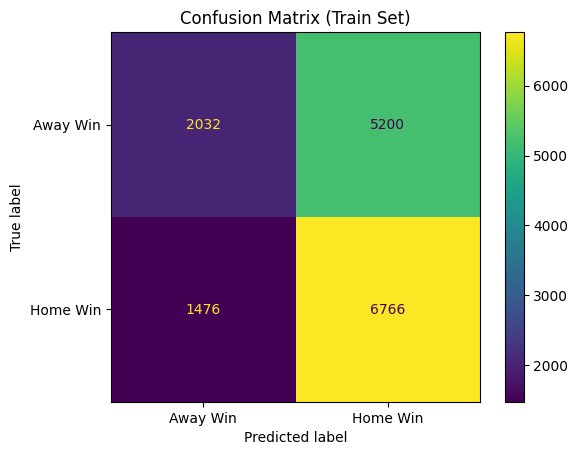

In [16]:
cm = confusion_matrix(y, pipeline.predict(X))
disp = ConfusionMatrixDisplay(cm, display_labels=["Away Win", "Home Win"])
disp.plot()
plt.title("Confusion Matrix (Train Set)")
plt.show()

## 9. Feature Importances

In [19]:
feat_names = X.columns.tolist()

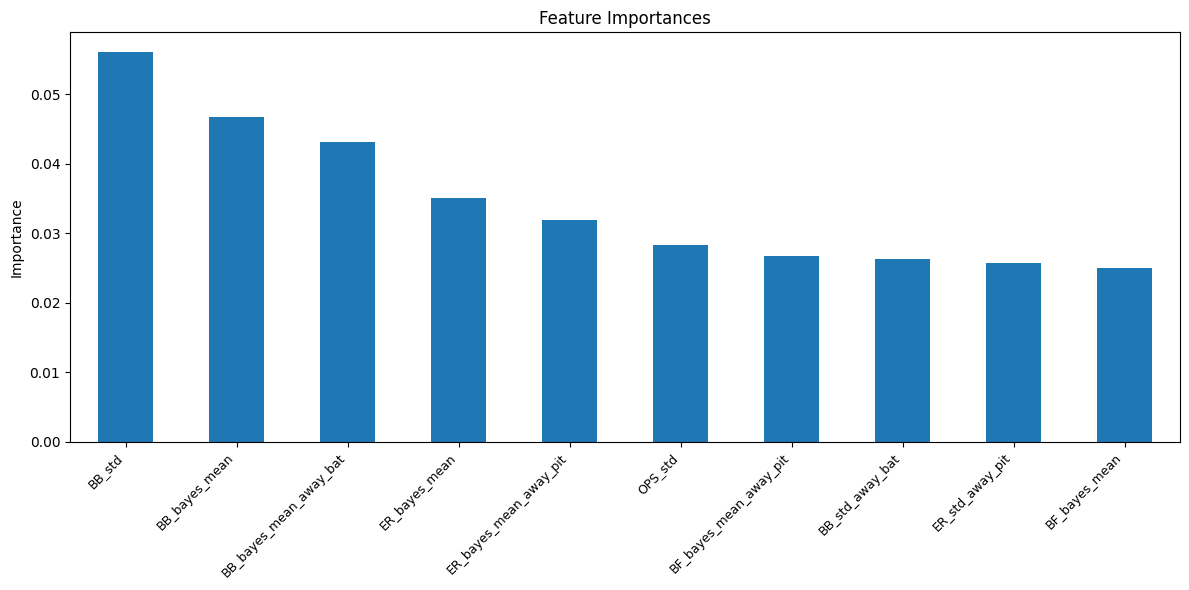

Top 10 features:
BB_std                    0.0561
BB_bayes_mean             0.0467
BB_bayes_mean_away_bat    0.0431
ER_bayes_mean             0.0350
ER_bayes_mean_away_pit    0.0319
OPS_std                   0.0282
BF_bayes_mean_away_pit    0.0267
BB_std_away_bat           0.0263
ER_std_away_pit           0.0258
BF_bayes_mean             0.0250
dtype: float64


In [21]:
importances = pipeline.named_steps["model"].feature_importances_
feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
feat_imp.head(10).plot(kind="bar")
plt.title("Feature Importances")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.tight_layout()
plt.show()

print("Top 10 features:")
print(feat_imp.head(10).round(4))

## 10. Save Model

In [22]:
with open(MODEL_PATH, "wb") as f:
    pickle.dump(pipeline, f)

print(f"Model saved to {MODEL_PATH}")
print(f"File size: {os.path.getsize(MODEL_PATH) / 1024:.1f} KB")

Model saved to /Users/nickchapman/pitch_predictor/backend/model/artifacts/model.pkl
File size: 188.2 KB


In [23]:
mlflow.sklearn.log_model(pipeline, "model")
mlflow.log_artifact(MODEL_PATH, "pickle")


2026/04/26 12:52:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/26 12:52:23 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


## 11. Smoke Test

In [24]:
with open(MODEL_PATH, "rb") as f:
    loaded_model = pickle.load(f)

prob = loaded_model.predict_proba(holdout_X)[0]
print(f"  Away win probability: {prob[0]:.3f}")
print(f"  Home win probability: {prob[1]:.3f}")


  Away win probability: 0.468
  Home win probability: 0.532


In [25]:
home_probs = pd.DataFrame(loaded_model.predict_proba(holdout_X))[1]

In [26]:
from sklearn.metrics import roc_auc_score,accuracy_score

In [27]:
roc_auc_score(holdout_y, home_probs)

0.5035996612083569

In [28]:
accuracy_score(holdout_y, home_probs>=.5)

0.5207100591715976

In [29]:
accuracy_score(holdout_y, [1 for x in holdout_y])


0.5443786982248521

In [30]:
roc_auc_score(holdout_y, [1 for x in holdout_y])

0.5

In [31]:
mlflow.log_metrics({
    "holdout_roc_auc":          float(roc_auc_score(holdout_y, home_probs)),
    "holdout_accuracy":         float(accuracy_score(holdout_y, home_probs >= 0.5)),
    "holdout_baseline_accuracy": float(accuracy_score(holdout_y, [1 for _ in holdout_y])),
    "n_holdout_games":           int(len(holdout_y)),
})
mlflow.end_run()
print(f"Run complete: {_run.info.run_id}")


Run complete: 1e13284626b44449b940e5fac1e3b36a


In [32]:
# Compare all runs
runs = mlflow.search_runs(experiment_names=["mlb-game-predictor-v1"])
runs[["run_id", "start_time", "params.years", "params.n_estimators", "params.window",
      "metrics.cv_accuracy_mean", "metrics.cv_accuracy_std",
      "metrics.train_accuracy", "metrics.holdout_roc_auc",
      "metrics.holdout_accuracy"]]\
    .sort_values("metrics.cv_accuracy_mean", ascending=False)


,run_id,start_time,params.years,params.n_estimators,params.window,metrics.cv_accuracy_mean,metrics.cv_accuracy_std,metrics.train_accuracy,metrics.holdout_roc_auc,metrics.holdout_accuracy
0,1e13284626b44449b940e5fac1e3b36a,2026-04-26 02:29:23.537000+00:00,"[2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]",200,10,0.555448,0.002978,0.568567,0.503600,0.520710
12,106fc1eb3efd4bb3873c66e82058101e,2026-04-26 00:38:19.267000+00:00,None,200,10,0.555448,0.002978,NaN,NaN,NaN
15,42af1515894f4f5d80cb419e1b0d559c,2026-04-26 00:18:36.481000+00:00,None,100,10,0.555384,0.005882,NaN,NaN,NaN
20,6e7ed69b30714e29bf55b9f08133ca44,2026-04-25 23:54:45.447000+00:00,None,100,10,0.555383,0.007832,NaN,NaN,NaN
6,92b6926f16ae491498b167d0246cab27,2026-04-26 01:18:18.414000+00:00,None,200,10,0.554672,0.005676,NaN,NaN,NaN
31,8ab33129ad214e98beee3916eda9869a,2026-04-25 23:23:06.213000+00:00,None,50,10,0.554543,0.006004,NaN,NaN,NaN
32,051865a8c80d4b42be764322a1213718,2026-04-25 23:21:06.901000+00:00,None,50,10,0.554349,0.006079,NaN,NaN,NaN
18,0c37357742044fc6974c016f4e278905,2026-04-26 00:02:43.855000+00:00,None,100,10,0.554155,0.002857,NaN,NaN,NaN
26,d5f0ea3c9a914cd2a9358c6baeca2267,2026-04-25 23:36:16.314000+00:00,None,50,10,0.554026,0.004975,NaN,NaN,NaN
58,7f96c43d335f43f6af9cf1ad4397b74a,2026-04-25 19:38:28.112000+00:00,"[2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]",50,10,0.553767,0.006724,0.590151,0.487454,0.514793
